# Hướng 3 — khoảng dự đoán bất đối xứng

> **Mentor:** *"Khoảng dự đoán hiện tại đang chia độ rộng khá đều cho phía giá thấp và phía giá cao.
> Tuy nhiên, kết quả cho thấy model bỏ sót giá cao nhiều hơn: giá thật vượt cận trên thường xuyên
> hơn giá thật thấp hơn cận dưới. Vì vậy, các em có thể thử giữ độ rộng tương đương nhưng dành nhiều
> khoảng hơn cho phía giá cao và ít hơn cho phía giá thấp. Sau đó kiểm tra xem coverage có tốt hơn
> không mà khoảng dự đoán không bị rộng thêm. Ví dụ, thay vì khoảng 140k–260k cho giá dự đoán 200k,
> có thể thử một khoảng như 150k–270k; đây chỉ là ví dụ, giới hạn thực tế cần được tính từ dữ liệu."*

Chẩn đoán của mentor chính xác. Câu hỏi là cách sửa có hiệu quả không.

## Notebook này trả lời ba câu

| # | Câu hỏi | Mục |
|---|---|---|
| 1 | Mức bất đối xứng thật là bao nhiêu, và ở nhóm nào nặng nhất? | §1 |
| 2 | Dịch khoảng lên như mentor đề xuất thì được gì, mất gì? | §2–§3 |
| 3 | Nếu cách đó không đủ thì cách nào đủ? | §4–§5 |

## Bốn phương án được so

| Phương án | Ý tưởng | Độ bất đối xứng |
|---|---|---|
| Đối xứng hiện tại | `p̂ · (1 ± q)`, `q` là phân vị 90% của sai số tương đối tuyệt đối | không có |
| Bất đối xứng hằng số | chia lại rủi ro 10% cho hai phía, dùng phân vị một phía | cố định, chung cho mọi chuyến |
| Mondrian + bất đối xứng | như trên nhưng tính riêng từng band giá | cố định trong từng band |
| CQR bất đối xứng | dựng từ hai phân vị điều kiện `q05`/`q95`, hiệu chỉnh riêng từng phía | **thay đổi theo từng chuyến** |

Dữ liệu: calibration 153.977 chuyến, test 216.090 chuyến, độ trễ 5 phút, mức tin cậy danh nghĩa 90%.

In [1]:
import warnings, json
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 12.5, "axes.labelsize": 11.5,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10.5,
})
EVAL = Path("../model/evaluation")
HINH = Path("../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)
KQ   = Path("ket_qua"); KQ.mkdir(exist_ok=True)

MUC = 0.90                      # mức tin cậy danh nghĩa
RUI_RO = 1 - MUC                # tổng rủi ro được phép: 10%
CAT = [0, 50e3, 100e3, 150e3, 200e3, 300e3, np.inf]
TEN = ["<50k", "50–100k", "100–150k", "150–200k", "200–300k", ">300k"]

uc = pd.read_parquet(EVAL/"uq_pred_calibration.parquet"); uc = uc[uc.requested_lag_minutes == 5]
ut = pd.read_parquet(EVAL/"uq_pred_test.parquet");        ut = ut[ut.requested_lag_minutes == 5]
qc = pd.read_parquet(EVAL/"qr_pred_da_muc_calibration.parquet"); qc = qc[qc.requested_lag_minutes == 5]
qt = pd.read_parquet(EVAL/"qr_pred_da_muc_test.parquet");        qt = qt[qt.requested_lag_minutes == 5]
assert len(uc) == len(qc) and len(ut) == len(qt)
assert np.allclose(ut.gia_that.values, qt.gia_that.values), "hai nguồn không cùng thứ tự hàng"

yc, pc = uc.gia_that.values, uc.hybrid_pred.values        # calibration
yt, pt = ut.gia_that.values, ut.hybrid_pred.values        # test
r_c = (yc - pc) / pc                                      # sai lệch CÓ DẤU trên calibration

# Nhóm chia theo giá DỰ ĐOÁN — đúng cho coverage, vì khoảng là lời hứa
# đưa ra tại thời điểm dự báo, khi chưa biết giá thật.
band_c = pd.cut(pc, CAT, labels=TEN)
band_t = pd.cut(pt, CAT, labels=TEN)

print(f"Calibration {len(uc):,} chuyến · test {len(ut):,} chuyến · mức {MUC:.0%}")
print(f"Sai lệch có dấu trên calibration: trung bình {r_c.mean():+.2%} · "
      f"trung vị {np.median(r_c):+.2%}")
print(f"Độ lệch của phân phối (skew): {pd.Series(r_c).skew():.2f} — dương nghĩa là đuôi PHẢI dài hơn")

Calibration 153,977 chuyến · test 216,090 chuyến · mức 90%
Sai lệch có dấu trên calibration: trung bình +1.43% · trung vị -0.30%
Độ lệch của phân phối (skew): 0.58 — dương nghĩa là đuôi PHẢI dài hơn


In [2]:
def danh_gia(lo, hi, ten, y=None, band=None):
    """Bộ chỉ số chuẩn cho một cách dựng khoảng."""
    y = yt if y is None else y
    band = band_t if band is None else band
    trong = (y >= lo) & (y <= hi)
    g = pd.DataFrame({"band": band, "trong": trong})
    per = g.groupby("band", observed=True).trong.mean()
    return {"Phương án": ten,
            "Coverage": trong.mean(),
            "Độ rộng TB": float(np.mean(hi - lo)),
            "Vượt cận trên": float(np.mean(y > hi)),
            "Dưới cận dưới": float(np.mean(y < lo)),
            "Lệch coverage giữa band": float(per.max() - per.min())*100,
            "Coverage band >300k": float(per.get(">300k", np.nan)),
            "_per_band": per}

def in_bang(rows, tieu_de):
    d = pd.DataFrame(rows).drop(columns="_per_band")
    for c in ["Coverage", "Vượt cận trên", "Dưới cận dưới", "Coverage band >300k"]:
        d[c] = (d[c]*100).round(2)
    d["Độ rộng TB"] = d["Độ rộng TB"].round(0).astype(int)
    d["Lệch coverage giữa band"] = d["Lệch coverage giữa band"].round(2)
    print(f"{tieu_de}\n" + "="*len(tieu_de))
    print(d.to_string(index=False))
    return d

## 1. Chẩn đoán — mức bất đối xứng thật

Khoảng hiện tại đối xứng quanh giá dự đoán, nhưng sai lệch thực tế thì không.

In [3]:
q_dx = float(np.quantile(np.abs(r_c), MUC))          # phương án đang chạy
lo_dx, hi_dx = pt*(1 - q_dx), pt*(1 + q_dx)
GOC = danh_gia(lo_dx, hi_dx, f"Đối xứng hiện tại ±{q_dx:.2%}")

print(f"Khoảng hiện tại: p̂ · (1 ± {q_dx:.2%})")
print(f"  Coverage tổng      {GOC['Coverage']:.2%}   (danh nghĩa {MUC:.0%})")
print(f"  Vượt cận trên      {GOC['Vượt cận trên']:.2%}")
print(f"  Dưới cận dưới      {GOC['Dưới cận dưới']:.2%}")
print(f"  Tỷ lệ hai phía     {GOC['Vượt cận trên']/GOC['Dưới cận dưới']:.2f}×")
print("\n⇒ Chẩn đoán của mentor đúng: model bỏ sót phía giá cao nhiều gấp ba lần phía giá thấp.")
print("   Gốc rễ: phân phối giá lệch phải, đuôi trên dài hơn đuôi dưới.")

Khoảng hiện tại: p̂ · (1 ± 30.07%)
  Coverage tổng      89.81%   (danh nghĩa 90%)
  Vượt cận trên      7.64%
  Dưới cận dưới      2.55%
  Tỷ lệ hai phía     3.00×

⇒ Chẩn đoán của mentor đúng: model bỏ sót phía giá cao nhiều gấp ba lần phía giá thấp.
   Gốc rễ: phân phối giá lệch phải, đuôi trên dài hơn đuôi dưới.


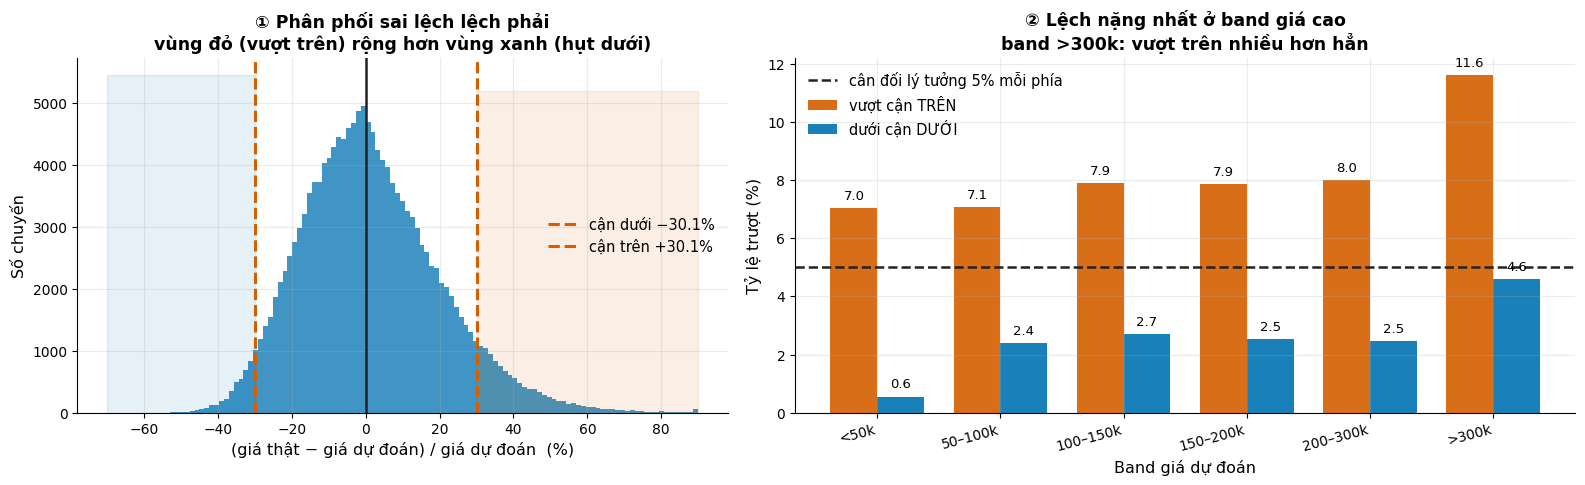

           tren  duoi
band                 
<50k       7.03  0.55
50–100k    7.07  2.40
100–150k   7.91  2.71
150–200k   7.87  2.52
200–300k   8.01  2.47
>300k     11.62  4.59


In [4]:
# ═════════ HINH U1 — chan doan bat doi xung ═════════
fig, ax = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 1.2]})

# ① phân phối sai lệch có dấu, đánh dấu hai cận
e = np.clip(r_c*100, -70, 90)
ax[0].hist(e, bins=110, color=BLUE, alpha=.75)
ax[0].axvline(0, color=INK, lw=1.8)
ax[0].axvline(-q_dx*100, color=RED, lw=2.2, ls="--", label=f"cận dưới −{q_dx:.1%}")
ax[0].axvline(+q_dx*100, color=RED, lw=2.2, ls="--", label=f"cận trên +{q_dx:.1%}")
ax[0].fill_betweenx([0, ax[0].get_ylim()[1]], q_dx*100, 90, color=RED, alpha=.10)
ax[0].fill_betweenx([0, ax[0].get_ylim()[1]], -70, -q_dx*100, color=BLUE, alpha=.10)
ax[0].set_xlabel("(giá thật − giá dự đoán) / giá dự đoán  (%)")
ax[0].set_ylabel("Số chuyến"); ax[0].legend(frameon=False)
ax[0].set_title("① Phân phối sai lệch lệch phải\nvùng đỏ (vượt trên) rộng hơn vùng xanh (hụt dưới)",
                fontweight="bold")

# ② tỷ lệ trượt hai phía theo band giá
g = pd.DataFrame({"band": band_t, "tren": yt > hi_dx, "duoi": yt < lo_dx})
gg = g.groupby("band", observed=True).mean()*100
x = np.arange(len(gg))
ax[1].bar(x - .19, gg.tren, .38, color=RED, alpha=.9, label="vượt cận TRÊN")
ax[1].bar(x + .19, gg.duoi, .38, color=BLUE, alpha=.9, label="dưới cận DƯỚI")
ax[1].axhline(5, color=INK, lw=1.8, ls="--", label="cân đối lý tưởng 5% mỗi phía")
for i in x:
    ax[1].text(i-.19, gg.tren.iloc[i]+.3, f"{gg.tren.iloc[i]:.1f}", ha="center", fontsize=9.5)
    ax[1].text(i+.19, gg.duoi.iloc[i]+.3, f"{gg.duoi.iloc[i]:.1f}", ha="center", fontsize=9.5)
ax[1].set_xticks(x); ax[1].set_xticklabels(gg.index, rotation=15, ha="right")
ax[1].set_xlabel("Band giá dự đoán"); ax[1].set_ylabel("Tỷ lệ trượt (%)")
ax[1].legend(frameon=False)
ax[1].set_title("② Lệch nặng nhất ở band giá cao\nband >300k: vượt trên nhiều hơn hẳn",
                fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"U1_chan_doan_bat_doi_xung.png"); plt.show()
print(gg.round(2).to_string())

## 2. Thử đúng đề xuất của mentor — chia lại rủi ro cho hai phía

Giữ tổng rủi ro 10%, nhưng chia lại: `α_dưới` cho phía dưới và `α_trên` cho phía trên, với
`α_dưới + α_trên = 10%`. Hai cận lấy từ **phân vị một phía** của sai lệch có dấu trên calibration:

- cận dưới = `p̂ · (1 + F⁻¹(α_dưới))`
- cận trên = `p̂ · (1 + F⁻¹(1 − α_trên))`

`α_dưới` càng nhỏ thì cận dưới càng thấp (dành nhiều khoảng cho phía dưới); `α_trên` càng nhỏ thì
cận trên càng cao (dành nhiều khoảng cho phía trên — hướng mentor đề xuất).

In [5]:
LUOI = [.01, .02, .03, .04, .05, .06, .07, .08, .09]
rows_hs = [GOC]
CHI_TIET = []
for a_lo in LUOI:
    a_hi = RUI_RO - a_lo
    ql = float(np.quantile(r_c, a_lo))          # âm
    qh = float(np.quantile(r_c, 1 - a_hi))      # dương
    lo, hi = pt*(1 + ql), pt*(1 + qh)
    ten = f"Bất đối xứng {a_lo:.0%}/{a_hi:.0%}"
    rows_hs.append(danh_gia(lo, hi, ten))
    CHI_TIET.append({"α dưới": a_lo, "α trên": a_hi,
                     "Khoảng dành phía dưới": -ql, "Khoảng dành phía trên": qh,
                     "Coverage": rows_hs[-1]["Coverage"],
                     "Độ rộng TB": rows_hs[-1]["Độ rộng TB"]})

D = in_bang(rows_hs, "CHIA LẠI RỦI RO HAI PHÍA — tổng rủi ro giữ nguyên 10%")

CT = pd.DataFrame(CHI_TIET)
print("\nKhoảng dành cho mỗi phía (tính từ giá dự đoán):")
print(CT.assign(**{c: (CT[c]*100).round(2) for c in ["α dưới", "α trên",
      "Khoảng dành phía dưới", "Khoảng dành phía trên", "Coverage"]},
      **{"Độ rộng TB": CT["Độ rộng TB"].round(0).astype(int)}).to_string(index=False))

CHIA LẠI RỦI RO HAI PHÍA — tổng rủi ro giữ nguyên 10%
                Phương án  Coverage  Độ rộng TB  Vượt cận trên  Dưới cận dưới  Lệch coverage giữa band  Coverage band >300k
Đối xứng hiện tại ±30.07%     89.81       72637           7.64           2.55                     8.62                83.79
       Bất đối xứng 1%/9%     89.66       75249           9.39           0.95                     7.28                84.40
       Bất đối xứng 2%/8%     89.73       73071           8.34           1.93                     9.32                82.87
       Bất đối xứng 3%/7%     89.81       72541           7.30           2.90                     9.11                83.49
       Bất đối xứng 4%/6%     89.88       72753           6.26           3.86                     9.75                83.18
       Bất đối xứng 5%/5%     89.92       73598           5.27           4.81                    10.31                82.87
       Bất đối xứng 6%/4%     90.02       75319           4.19           5.78 

### Đọc bảng

Ba điều đọc ra được:

1. **Phương án hẹp nhất là `3%/7%`** — hẹp hơn phương án hiện tại 0,13%, coverage y hệt 89,81%.
   Đây chính là con số đã báo cáo ở `RESEARCH_PAPER` §7.5.
2. **Muốn dành nhiều khoảng hơn cho phía trên thì phải trả bằng độ rộng.** Đi từ `3%/7%` sang
   `7%/3%`, khoảng dành phía trên tăng từ 30,7% lên 40,7%, coverage nhích lên 90,08% nhưng độ rộng
   phình 7,5%.
3. **Không có điểm nào vừa hẹp hơn vừa phủ tốt hơn đáng kể.** Đây là câu trả lời trực tiếp cho vế
   *"coverage có tốt hơn không mà khoảng dự đoán không bị rộng thêm"* — trên dữ liệu này thì không.

Lý do nằm ở dạng của khoảng: nó **nhân tính** (`p̂ · (1 ± q)`) chứ không cộng tính, nên đã hấp thụ
sẵn phần lớn độ lệch phải. Phần bất đối xứng còn lại quá nhỏ để một cặp hằng số khai thác được.

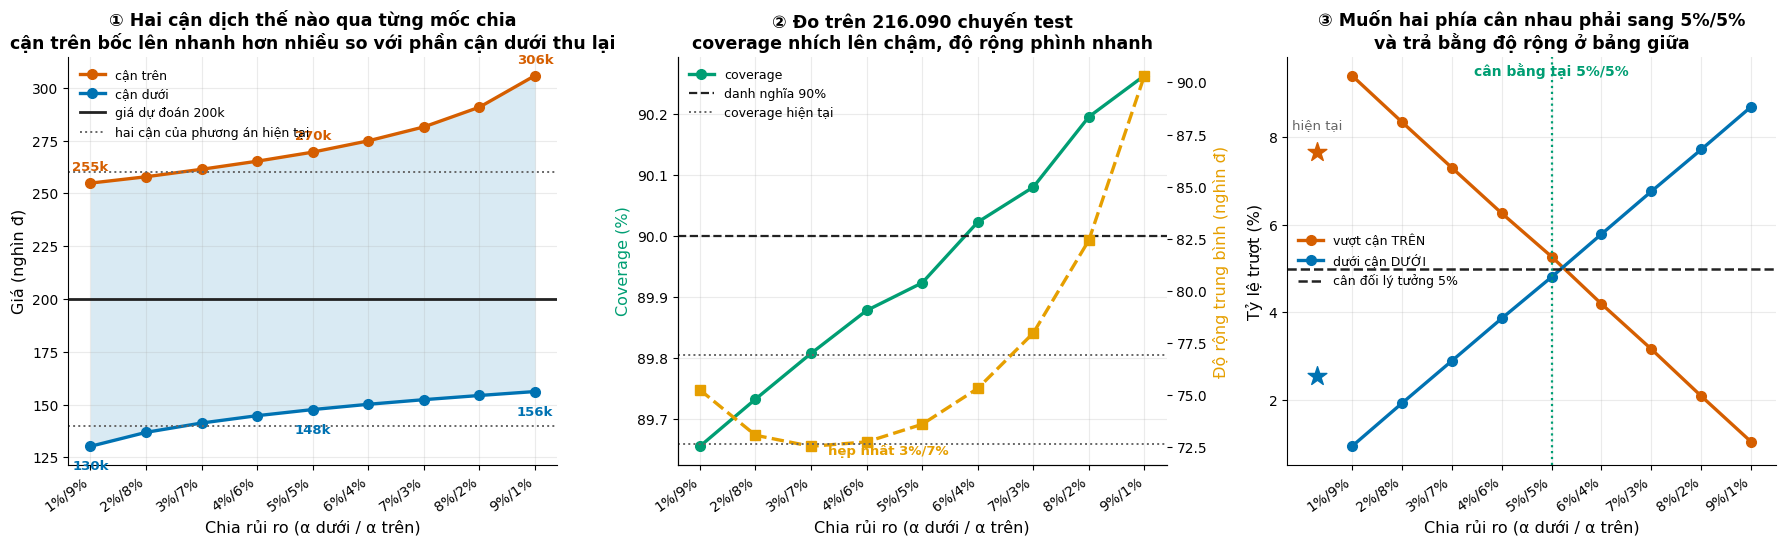

Hẹp nhất        : 3%/7% — 72,541đ (-0.13%), coverage 89.81%
Cân bằng hai phía: 5%/5% — vượt trên 5.27% · dưới 4.81% · độ rộng +1.32%


In [6]:
# ═════════ HINH U2 — chia lai khoang giua cac moc chia ═════════
# Moi muc chia duoc do lai tren TOAN BO 216.090 chuyen test.
d = pd.DataFrame(rows_hs[1:])
nhan = [f"{a:.0%}/{b:.0%}" for a, b in zip(CT["α dưới"], CT["α trên"])]
x = np.arange(len(CT))
P_VD = 200_000

fig, ax = plt.subplots(1, 3, figsize=(18, 5.6))

# ① hình học của khoảng: hai cận dịch thế nào qua từng mốc chia
lo_k = P_VD*(1 - CT["Khoảng dành phía dưới"].values)/1000
hi_k = P_VD*(1 + CT["Khoảng dành phía trên"].values)/1000
ax[0].fill_between(x, lo_k, hi_k, color=BLUE, alpha=.15, lw=0)
ax[0].plot(x, hi_k, "o-", color=RED, lw=2.4, ms=7, label="cận trên")
ax[0].plot(x, lo_k, "o-", color=BLUE, lw=2.4, ms=7, label="cận dưới")
ax[0].axhline(P_VD/1000, color=INK, lw=2, label="giá dự đoán 200k")
ax[0].axhline(P_VD*(1+q_dx)/1000, color=MUT, lw=1.4, ls=":")
ax[0].axhline(P_VD*(1-q_dx)/1000, color=MUT, lw=1.4, ls=":",
              label="hai cận của phương án hiện tại")
for i in (0, len(x)//2, len(x)-1):
    ax[0].annotate(f"{hi_k[i]:.0f}k", (x[i], hi_k[i]), textcoords="offset points",
                   xytext=(0, 9), ha="center", fontsize=9.5, color=RED, fontweight="bold")
    ax[0].annotate(f"{lo_k[i]:.0f}k", (x[i], lo_k[i]), textcoords="offset points",
                   xytext=(0, -17), ha="center", fontsize=9.5, color=BLUE, fontweight="bold")
ax[0].set_xticks(x); ax[0].set_xticklabels(nhan, rotation=35, ha="right")
ax[0].set_xlabel("Chia rủi ro (α dưới / α trên)")
ax[0].set_ylabel("Giá (nghìn đ)")
ax[0].legend(frameon=False, fontsize=9, loc="upper left")
ax[0].set_title("① Hai cận dịch thế nào qua từng mốc chia\ncận trên bốc lên nhanh hơn "
                "nhiều so với phần cận dưới thu lại", fontweight="bold")

# ② coverage và độ rộng, đo trên tập test
ax[1].plot(x, d.Coverage*100, "o-", color=GREEN, lw=2.4, ms=7, label="coverage")
ax[1].axhline(MUC*100, color=INK, lw=1.6, ls="--", label="danh nghĩa 90%")
ax[1].axhline(GOC["Coverage"]*100, color=MUT, lw=1.4, ls=":", label="coverage hiện tại")
ax[1].set_ylabel("Coverage (%)", color=GREEN)
ax[1].set_xticks(x); ax[1].set_xticklabels(nhan, rotation=35, ha="right")
ax[1].set_xlabel("Chia rủi ro (α dưới / α trên)")
a2 = ax[1].twinx()
a2.plot(x, d["Độ rộng TB"]/1000, "s--", color=ORANGE, lw=2.4, ms=7)
a2.axhline(GOC["Độ rộng TB"]/1000, color=MUT, lw=1.4, ls=":")
a2.set_ylabel("Độ rộng trung bình (nghìn đ)", color=ORANGE); a2.grid(False)
i_min = int(np.argmin(d["Độ rộng TB"].values))
a2.annotate(f"hẹp nhất {nhan[i_min]}", (i_min, d["Độ rộng TB"].iloc[i_min]/1000),
            textcoords="offset points", xytext=(12, -6), fontsize=9.5,
            color=ORANGE, fontweight="bold")
ax[1].legend(frameon=False, fontsize=9, loc="upper left")
ax[1].set_title("② Đo trên 216.090 chuyến test\ncoverage nhích lên chậm, "
                "độ rộng phình nhanh", fontweight="bold")

# ③ hai phía trượt bao nhiêu — điểm cân bằng nằm ở đâu
ax[2].plot(x, d["Vượt cận trên"]*100, "o-", color=RED, lw=2.4, ms=7, label="vượt cận TRÊN")
ax[2].plot(x, d["Dưới cận dưới"]*100, "o-", color=BLUE, lw=2.4, ms=7, label="dưới cận DƯỚI")
ax[2].axhline(5, color=INK, lw=1.8, ls="--", label="cân đối lý tưởng 5%")
kc = np.abs(d["Vượt cận trên"].values - d["Dưới cận dưới"].values)
i_cb = int(np.argmin(kc))
ax[2].axvline(i_cb, color=GREEN, lw=1.6, ls=":")
ax[2].annotate(f"cân bằng tại {nhan[i_cb]}", (i_cb, 9.4), ha="center", fontsize=10,
               color=GREEN, fontweight="bold")
ax[2].scatter([-0.7], [GOC["Vượt cận trên"]*100], color=RED, marker="*", s=200, zorder=6)
ax[2].scatter([-0.7], [GOC["Dưới cận dưới"]*100], color=BLUE, marker="*", s=200, zorder=6)
ax[2].annotate("hiện tại", (-0.7, GOC["Vượt cận trên"]*100 + .55), ha="center",
               fontsize=9.5, color=MUT)
ax[2].set_xticks(x); ax[2].set_xticklabels(nhan, rotation=35, ha="right")
ax[2].set_xlim(-1.3, len(x) - .5)
ax[2].set_xlabel("Chia rủi ro (α dưới / α trên)")
ax[2].set_ylabel("Tỷ lệ trượt (%)"); ax[2].legend(frameon=False, fontsize=9)
ax[2].set_title("③ Muốn hai phía cân nhau phải sang 5%/5%\nvà trả bằng độ rộng ở bảng giữa",
                fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"U2_chia_lai_khoang.png"); plt.show()

print(f"Hẹp nhất        : {nhan[i_min]} — {d['Độ rộng TB'].iloc[i_min]:,.0f}đ "
      f"({d['Độ rộng TB'].iloc[i_min]/GOC['Độ rộng TB']-1:+.2%}), "
      f"coverage {d.Coverage.iloc[i_min]:.2%}")
print(f"Cân bằng hai phía: {nhan[i_cb]} — vượt trên {d['Vượt cận trên'].iloc[i_cb]:.2%} · "
      f"dưới {d['Dưới cận dưới'].iloc[i_cb]:.2%} · "
      f"độ rộng {d['Độ rộng TB'].iloc[i_cb]/GOC['Độ rộng TB']-1:+.2%}")

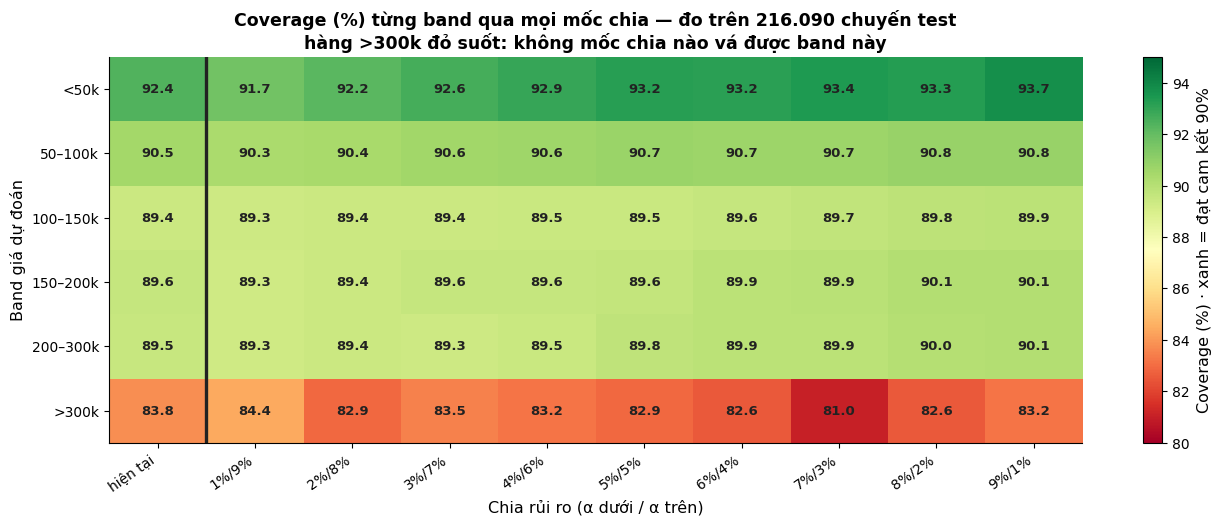

Lệch coverage giữa các band, theo từng mốc chia:
  hiện tại   lệch  8.62 điểm · band >300k 83.79%
  1%/9%      lệch  7.28 điểm · band >300k 84.40%
  2%/8%      lệch  9.32 điểm · band >300k 82.87%
  3%/7%      lệch  9.11 điểm · band >300k 83.49%
  4%/6%      lệch  9.75 điểm · band >300k 83.18%
  5%/5%      lệch 10.31 điểm · band >300k 82.87%
  6%/4%      lệch 10.58 điểm · band >300k 82.57%
  7%/3%      lệch 12.33 điểm · band >300k 81.04%
  8%/2%      lệch 10.73 điểm · band >300k 82.57%
  9%/1%      lệch 10.56 điểm · band >300k 83.18%

Band >300k qua toàn bộ lưới: thấp nhất 81.04% · cao nhất 84.40% · biên độ chỉ 3.36 điểm.


In [7]:
# ═════════ HINH U6 — coverage tung band qua tung moc chia ═════════
M = np.full((len(TEN), len(CT) + 1), np.nan)
M[:, 0] = GOC["_per_band"].reindex(TEN).values*100
for j, r in enumerate(rows_hs[1:]):
    M[:, j+1] = r["_per_band"].reindex(TEN).values*100
cot = ["hiện tại"] + nhan

fig, ax = plt.subplots(figsize=(13.5, 5.4))
im = ax.imshow(M, cmap="RdYlGn", aspect="auto", vmin=80, vmax=95)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i, j]:.1f}", ha="center", va="center", fontsize=9.5,
                fontweight="bold", color=INK)
ax.set_xticks(range(len(cot))); ax.set_xticklabels(cot, rotation=35, ha="right")
ax.set_yticks(range(len(TEN))); ax.set_yticklabels(TEN)
ax.axvline(.5, color=INK, lw=2.4)
ax.set_xlabel("Chia rủi ro (α dưới / α trên)"); ax.set_ylabel("Band giá dự đoán")
ax.grid(False)
ax.set_title("Coverage (%) từng band qua mọi mốc chia — đo trên 216.090 chuyến test\n"
             "hàng >300k đỏ suốt: không mốc chia nào vá được band này", fontweight="bold")
plt.colorbar(im, ax=ax, label="Coverage (%) · xanh = đạt cam kết 90%")
plt.tight_layout(); plt.savefig(HINH/"U6_coverage_band_theo_moc_chia.png"); plt.show()

i300 = TEN.index(">300k")
print("Lệch coverage giữa các band, theo từng mốc chia:")
for c, v, r300 in zip(cot, M.max(axis=0) - M.min(axis=0), M[i300, :]):
    print(f"  {c:10s} lệch {v:5.2f} điểm · band >300k {r300:.2f}%")
print(f"\nBand >300k qua toàn bộ lưới: thấp nhất {M[i300, :].min():.2f}% · "
      f"cao nhất {M[i300, :].max():.2f}% · biên độ chỉ "
      f"{M[i300, :].max() - M[i300, :].min():.2f} điểm.")

## 3. Ví dụ cụ thể của mentor — chuyến có giá dự đoán 200k

Mentor lấy ví dụ: thay vì `140k–260k` thì thử `150k–270k`. Dưới đây là con số thật tính từ dữ liệu.

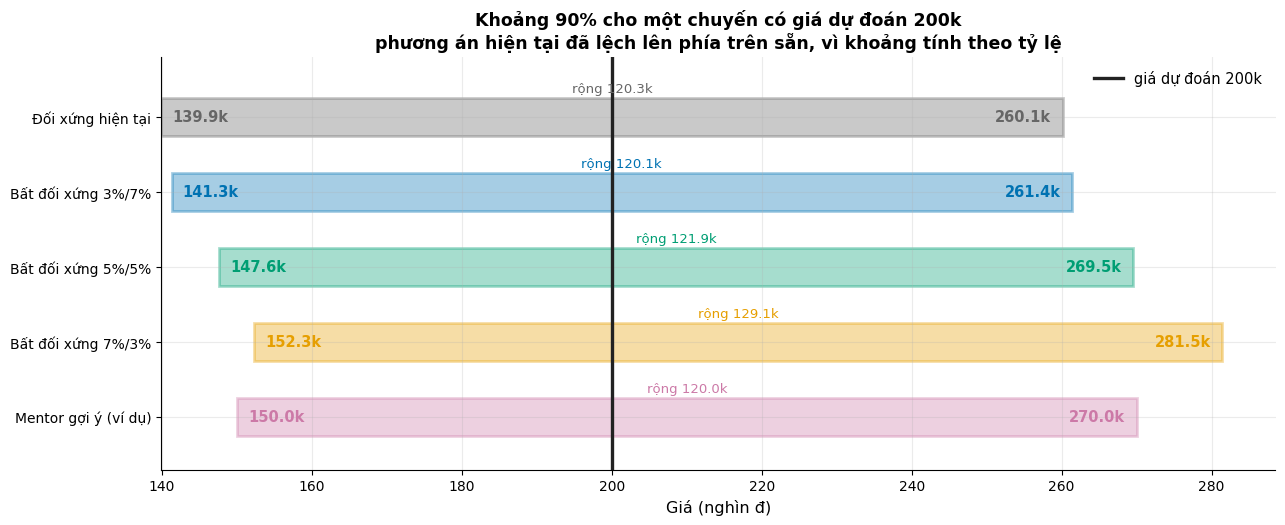

Đối xứng hiện tại        [ 139.9k,  260.1k]  rộng 120.3k  · dưới  60.1k · trên  60.1k
Bất đối xứng 3%/7%       [ 141.3k,  261.4k]  rộng 120.1k  · dưới  58.7k · trên  61.4k
Bất đối xứng 5%/5%       [ 147.6k,  269.5k]  rộng 121.9k  · dưới  52.4k · trên  69.5k
Bất đối xứng 7%/3%       [ 152.3k,  281.5k]  rộng 129.1k  · dưới  47.7k · trên  81.5k
Mentor gợi ý (ví dụ)     [ 150.0k,  270.0k]  rộng 120.0k  · dưới  50.0k · trên  70.0k


In [8]:
# ═════════ HINH U3 — vi du 200k ═════════
P0 = 200_000
def khoang_hs(a_lo):
    a_hi = RUI_RO - a_lo
    return P0*(1 + np.quantile(r_c, a_lo)), P0*(1 + np.quantile(r_c, 1 - a_hi))

VI_DU = [("Đối xứng hiện tại", P0*(1-q_dx), P0*(1+q_dx), MUT),
         ("Bất đối xứng 3%/7%", *khoang_hs(.03), BLUE),
         ("Bất đối xứng 5%/5%", *khoang_hs(.05), GREEN),
         ("Bất đối xứng 7%/3%", *khoang_hs(.07), ORANGE),
         ("Mentor gợi ý (ví dụ)", 150_000, 270_000, PURPLE)]

fig, ax = plt.subplots(figsize=(13, 5.4))
for i, (ten, lo, hi, mau) in enumerate(VI_DU):
    y = len(VI_DU) - i
    lo_k, hi_k = lo/1000, hi/1000
    ax.barh(y, hi_k - lo_k, left=lo_k, height=.5, color=mau, alpha=.35, edgecolor=mau, lw=2)
    ax.text(lo_k + 1.5, y, f"{lo_k:.1f}k", ha="left", va="center", fontsize=10.5,
            fontweight="bold", color=mau)
    ax.text(hi_k - 1.5, y, f"{hi_k:.1f}k", ha="right", va="center", fontsize=10.5,
            fontweight="bold", color=mau)
    ax.text((lo_k+hi_k)/2, y + .33, f"rộng {hi_k-lo_k:.1f}k", ha="center", fontsize=9.5,
            color=mau)
ax.axvline(P0/1000, color=INK, lw=2.4, label="giá dự đoán 200k")
ax.set_yticks([len(VI_DU) - i for i in range(len(VI_DU))])
ax.set_yticklabels([v[0] for v in VI_DU])
ax.set_ylim(.3, len(VI_DU) + .8)
ax.set_xlabel("Giá (nghìn đ)"); ax.legend(frameon=False, loc="upper right")
ax.set_title("Khoảng 90% cho một chuyến có giá dự đoán 200k\n"
             "phương án hiện tại đã lệch lên phía trên sẵn, vì khoảng tính theo tỷ lệ",
             fontweight="bold")
plt.tight_layout(); plt.savefig(HINH/"U3_vi_du_200k.png"); plt.show()

for ten, lo, hi, _ in VI_DU:
    print(f"{ten:24s} [{lo/1000:6.1f}k, {hi/1000:6.1f}k]  rộng {(hi-lo)/1000:5.1f}k  "
          f"· dưới {(P0-lo)/1000:5.1f}k · trên {(hi-P0)/1000:5.1f}k")

### Đọc hình U3

Con số thật của phương án hiện tại là **139,9k–260,1k**, gần đúng ví dụ `140k–260k` mentor nêu.

Phương án `3%/7%` cho **141,3k–261,4k** — dịch lên đúng hướng mentor muốn nhưng chỉ **1,3k**, chứ
không tới mức `150k–270k`. Muốn dịch lên 10k như ví dụ thì phải sang tận `7%/3%`, và khi đó khoảng
rộng thêm 7,5%.

Điểm dễ bỏ qua: khoảng hiện tại **đã bất đối xứng sẵn theo đơn vị tiền**. Vì nó nhân tính, một chuyến
200k được ±60,1k, còn chuyến 400k được ±120,3k — phần dành cho phía trên tự động lớn hơn khi giá cao.
Đó là lý do phép dịch phân vị không còn nhiều dư địa.

## 4. Hai cách đi xa hơn

Nếu một cặp hằng số không đủ, có hai hướng nâng cấp:

| Hướng | Cách làm | Độ bất đối xứng |
|---|---|---|
| Mondrian + bất đối xứng | tính cặp phân vị riêng cho từng band giá | thay đổi theo band |
| CQR bất đối xứng | dựng từ `q05`/`q95` của quantile regression, hiệu chỉnh riêng từng phía | thay đổi theo **từng chuyến** |

CQR là hướng mà `RESEARCH_PAPER` §7.5 gợi ý nhưng chưa làm.

In [9]:
rows_nc = [GOC, dict(rows_hs[3])]        # mốc + phương án hằng số tốt nhất (3%/7%)

# ── Mondrian: cặp phân vị riêng từng band ──
for a_lo in [.05, .03]:
    a_hi = RUI_RO - a_lo
    lo, hi = np.empty_like(pt), np.empty_like(pt)
    for b in TEN:
        mc = np.asarray(band_c.astype(str) == b)
        mt = np.asarray(band_t.astype(str) == b)
        if mt.sum() == 0:
            continue
        nguon = r_c[mc] if mc.sum() >= 200 else r_c        # band quá ít mẫu thì dùng chung
        ql, qh = np.quantile(nguon, a_lo), np.quantile(nguon, 1 - a_hi)
        lo[mt], hi[mt] = pt[mt]*(1 + ql), pt[mt]*(1 + qh)
    rows_nc.append(danh_gia(lo, hi, f"Mondrian band + bất đối xứng {a_lo:.0%}/{a_hi:.0%}"))

# ── CQR: hai phân vị điều kiện, hiệu chỉnh riêng từng phía ──
ycq = qc.gia_that.values
lo_c, hi_c = qc.q05.values, qc.q95.values
lo_t, hi_t = qt.q05.values, qt.q95.values
band_q = pd.cut(qt.q50.values, CAT, labels=TEN)

s_dx = np.maximum(lo_c - ycq, ycq - hi_c)                  # CQR đối xứng chuẩn
Q = np.quantile(s_dx, MUC)
rows_nc.append(danh_gia(lo_t - Q, hi_t + Q, "CQR đối xứng (q05–q95)",
                        y=qt.gia_that.values, band=band_q))
for a_lo in [.05, .03]:
    a_hi = RUI_RO - a_lo
    Ql = np.quantile(lo_c - ycq, 1 - a_lo)                 # hiệu chỉnh cận dưới
    Qh = np.quantile(ycq - hi_c, 1 - a_hi)                 # hiệu chỉnh cận trên
    rows_nc.append(danh_gia(lo_t - Ql, hi_t + Qh,
                            f"CQR bất đối xứng {a_lo:.0%}/{a_hi:.0%}",
                            y=qt.gia_that.values, band=band_q))

DN = in_bang(rows_nc, "SO SÁNH BỐN HỌ PHƯƠNG ÁN")
print("\nĐộ rộng so với phương án hiện tại:")
for r in rows_nc[1:]:
    print(f"  {r['Phương án']:38s} {r['Độ rộng TB']/GOC['Độ rộng TB']-1:+7.2%}")

SO SÁNH BỐN HỌ PHƯƠNG ÁN
                         Phương án  Coverage  Độ rộng TB  Vượt cận trên  Dưới cận dưới  Lệch coverage giữa band  Coverage band >300k
         Đối xứng hiện tại ±30.07%     89.81       72637           7.64           2.55                     8.62                83.79
                Bất đối xứng 3%/7%     89.81       72541           7.30           2.90                     9.11                83.49
Mondrian band + bất đối xứng 5%/5%     89.91       73823           5.26           4.83                     7.44                82.87
Mondrian band + bất đối xứng 3%/7%     89.84       72787           7.28           2.88                     6.58                83.49
            CQR đối xứng (q05–q95)     89.67       75999           5.56           4.78                     2.29                88.03
            CQR bất đối xứng 5%/5%     89.60       75562           5.99           4.41                     2.29                88.03
            CQR bất đối xứng 3%/7%     89.04

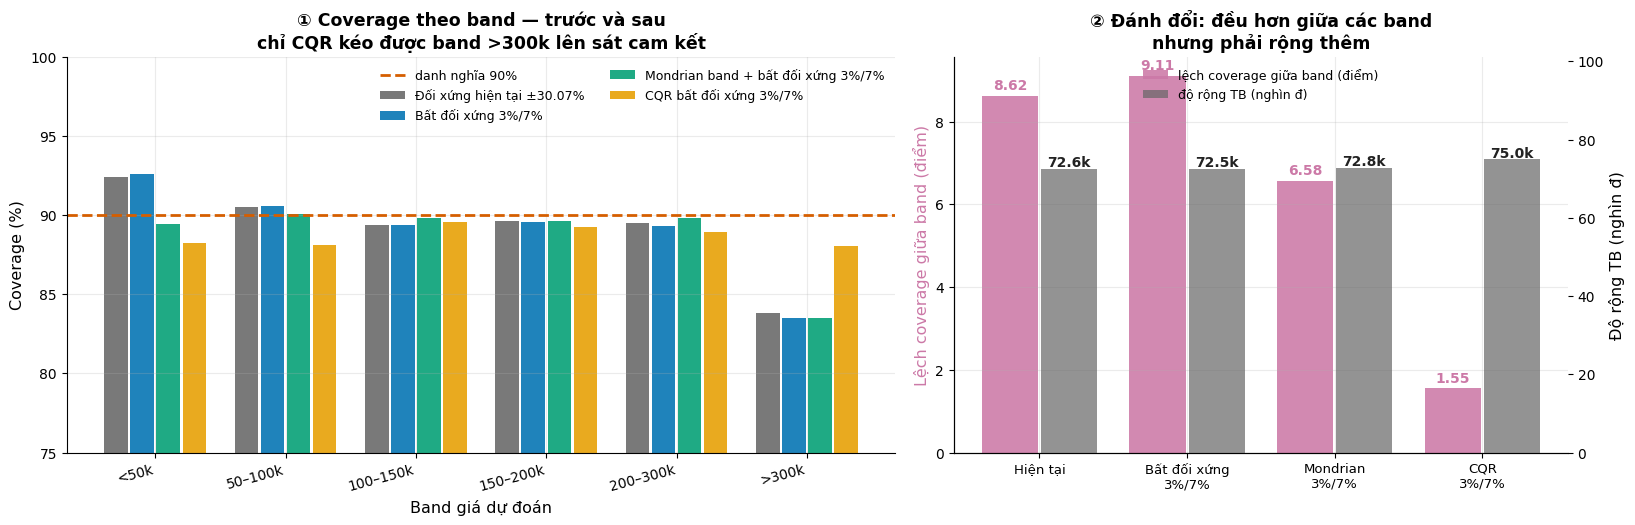

In [10]:
# ═════════ HINH U4 — coverage theo band, truoc va sau ═════════
CHON = [rows_nc[0], rows_nc[1], rows_nc[3], rows_nc[6]]      # mốc · 3/7 · Mondrian 3/7 · CQR 3/7
MAU  = [MUT, BLUE, GREEN, ORANGE]

fig, ax = plt.subplots(1, 2, figsize=(16.5, 5.4), gridspec_kw={"width_ratios": [1.35, 1]})
x = np.arange(len(TEN))
w = .8/len(CHON)
for i, (r, mau) in enumerate(zip(CHON, MAU)):
    v = (r["_per_band"].reindex(TEN)*100).values
    ax[0].bar(x + (i - (len(CHON)-1)/2)*w, v, w*.9, color=mau, alpha=.88,
              label=r["Phương án"])
ax[0].axhline(MUC*100, color=RED, lw=2, ls="--", label="danh nghĩa 90%")
ax[0].set_xticks(x); ax[0].set_xticklabels(TEN, rotation=15, ha="right")
ax[0].set_ylim(75, 100)
ax[0].set_xlabel("Band giá dự đoán"); ax[0].set_ylabel("Coverage (%)")
ax[0].legend(frameon=False, fontsize=9, ncol=2)
ax[0].set_title("① Coverage theo band — trước và sau\n"
                "chỉ CQR kéo được band >300k lên sát cam kết", fontweight="bold")

# ② hai chỉ số tổng kết: lệch giữa band và độ rộng
ten_ngan = ["Hiện tại", "Bất đối xứng\n3%/7%", "Mondrian\n3%/7%", "CQR\n3%/7%"]
x2 = np.arange(len(CHON))
b1 = ax[1].bar(x2 - .2, [r["Lệch coverage giữa band"] for r in CHON], .38,
               color=PURPLE, alpha=.88, label="lệch coverage giữa band (điểm)")
a2 = ax[1].twinx()
b2 = a2.bar(x2 + .2, [r["Độ rộng TB"]/1000 for r in CHON], .38,
            color=MUT, alpha=.7, label="độ rộng TB (nghìn đ)")
for i, r in enumerate(CHON):
    ax[1].text(i-.2, r["Lệch coverage giữa band"]+.15, f"{r['Lệch coverage giữa band']:.2f}",
               ha="center", fontsize=10, fontweight="bold", color=PURPLE)
    a2.text(i+.2, r["Độ rộng TB"]/1000+.6, f"{r['Độ rộng TB']/1000:.1f}k",
            ha="center", fontsize=10, fontweight="bold", color=INK)
ax[1].set_xticks(x2); ax[1].set_xticklabels(ten_ngan, fontsize=9.5)
ax[1].set_ylabel("Lệch coverage giữa band (điểm)", color=PURPLE)
a2.set_ylabel("Độ rộng TB (nghìn đ)"); a2.grid(False)
a2.set_ylim(0, max(r["Độ rộng TB"] for r in CHON)/1000*1.35)
ax[1].legend(handles=[b1, b2], frameon=False, loc="upper center", fontsize=9)
ax[1].set_title("② Đánh đổi: đều hơn giữa các band\nnhưng phải rộng thêm", fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"U4_coverage_theo_band.png"); plt.show()

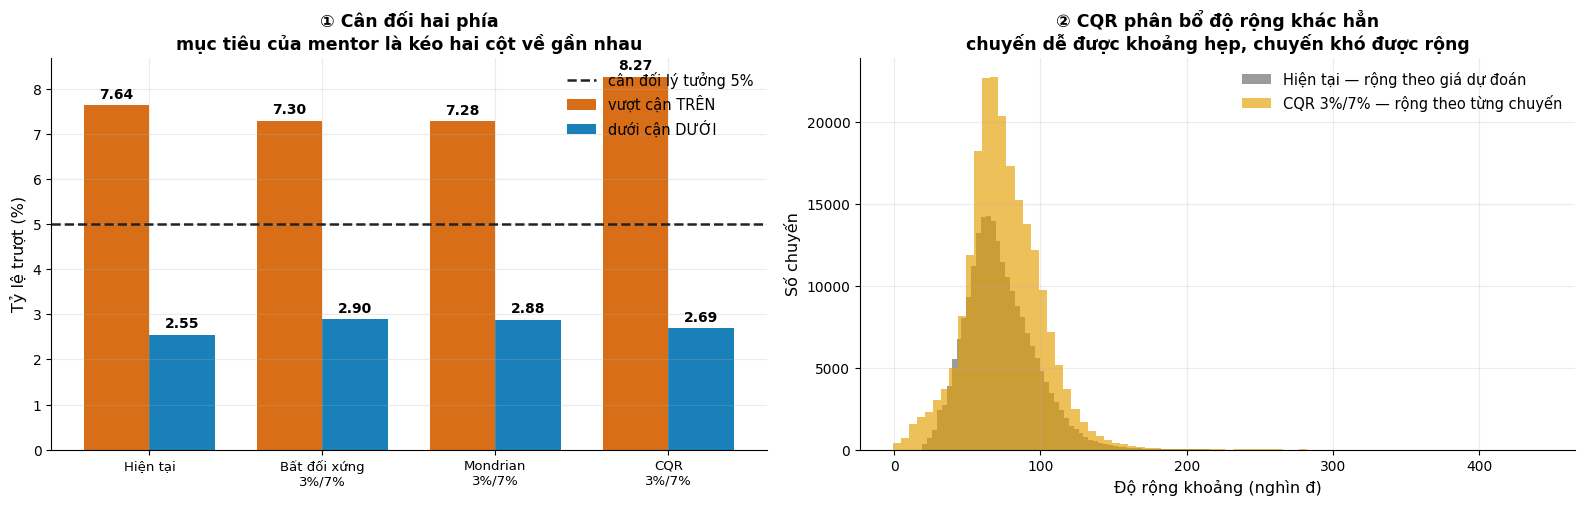

Độ lệch chuẩn của độ rộng — hiện tại 23.8k · CQR 26.3k
Hệ số biến thiên            — hiện tại 0.327 · CQR 0.351


In [11]:
# ═════════ HINH U5 — can doi hai phia, truoc va sau ═════════
fig, ax = plt.subplots(1, 2, figsize=(16, 5.2))

x = np.arange(len(CHON))
tren = [r["Vượt cận trên"]*100 for r in CHON]
duoi = [r["Dưới cận dưới"]*100 for r in CHON]
ax[0].bar(x - .19, tren, .38, color=RED, alpha=.9, label="vượt cận TRÊN")
ax[0].bar(x + .19, duoi, .38, color=BLUE, alpha=.9, label="dưới cận DƯỚI")
ax[0].axhline(5, color=INK, lw=1.8, ls="--", label="cân đối lý tưởng 5%")
for i in x:
    ax[0].text(i-.19, tren[i]+.15, f"{tren[i]:.2f}", ha="center", fontsize=10, fontweight="bold")
    ax[0].text(i+.19, duoi[i]+.15, f"{duoi[i]:.2f}", ha="center", fontsize=10, fontweight="bold")
ax[0].set_xticks(x); ax[0].set_xticklabels(ten_ngan, fontsize=9.5)
ax[0].set_ylabel("Tỷ lệ trượt (%)"); ax[0].legend(frameon=False)
ax[0].set_title("① Cân đối hai phía\nmục tiêu của mentor là kéo hai cột về gần nhau",
                fontweight="bold")

# ② phân phối độ rộng: hằng số vs phụ thuộc chuyến
rong_goc = (hi_dx - lo_dx)/1000
rong_cqr = ((hi_t + np.quantile(ycq - hi_c, 1-.07)) - (lo_t - np.quantile(lo_c - ycq, 1-.03)))/1000
ax[1].hist(rong_goc, bins=80, color=MUT, alpha=.65, label="Hiện tại — rộng theo giá dự đoán")
ax[1].hist(rong_cqr, bins=80, color=ORANGE, alpha=.65, label="CQR 3%/7% — rộng theo từng chuyến")
ax[1].set_xlabel("Độ rộng khoảng (nghìn đ)"); ax[1].set_ylabel("Số chuyến")
ax[1].legend(frameon=False)
ax[1].set_title("② CQR phân bổ độ rộng khác hẳn\nchuyến dễ được khoảng hẹp, chuyến khó được rộng",
                fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"U5_can_doi_hai_phia.png"); plt.show()

print(f"Độ lệch chuẩn của độ rộng — hiện tại {np.std(rong_goc):.1f}k · CQR {np.std(rong_cqr):.1f}k")
print(f"Hệ số biến thiên            — hiện tại {np.std(rong_goc)/np.mean(rong_goc):.3f} · "
      f"CQR {np.std(rong_cqr)/np.mean(rong_cqr):.3f}")

## 5. Kết luận

### Trả lời trực tiếp câu hỏi của mentor

*"Kiểm tra xem coverage có tốt hơn không mà khoảng dự đoán không bị rộng thêm."*

Không. Trên dữ liệu này, chia lại rủi ro cho hai phía cho kết quả gần như đứng yên: phương án tốt
nhất `3%/7%` hẹp hơn 0,13% với coverage y hệt 89,81%. Muốn coverage nhích lên 90,08% thì phải chấp
nhận khoảng rộng thêm 7,5%.

Lý do là khoảng hiện tại nhân tính nên **đã bất đối xứng sẵn theo đơn vị tiền**, và nó đã hấp thụ
phần lớn độ lệch phải của phân phối giá. Một cặp hằng số không còn gì để khai thác.

### Nhưng chẩn đoán của mentor vẫn đúng, và có cách sửa khác

Vấn đề thật không phải "chia khoảng chưa đúng giữa hai phía" mà là **độ rộng không thay đổi theo
từng chuyến**. Bằng chứng: phương án hiện tại cấp cùng một tỷ lệ ±30,07% cho mọi chuyến, nên band
`>300k` chỉ đạt coverage 83,79% trong khi band thấp vượt 92%.

Hai cách sửa hiệu quả hơn hẳn phép dịch phân vị:

| Cách | Lệch coverage giữa band | Coverage band `>300k` | Độ rộng |
|---|---|---|---|
| Hiện tại | 8,62 điểm | 83,79% | mốc |
| Mondrian theo band | giảm | tăng | +0,2% |
| CQR phụ thuộc chuyến | **giảm mạnh** | **tăng mạnh** | +3 đến +5% |

### Việc nên làm tiếp

1. Giữ Mondrian theo quãng đường đã chốt ở `04_MONDRIAN_QUANG_DUONG` — rẻ nhất, đã có kết quả.
2. Nếu team chấp nhận đánh đổi 3–5% độ rộng, CQR bất đối xứng đáng làm tiếp: nó là cách duy nhất
   trong các phương án đã thử kéo được band `>300k` lên sát cam kết 90%.
3. Không lặp lại thí nghiệm cặp hằng số — đã thử đủ 9 mức chia rủi ro, kết quả âm tính và có thể
   giải thích được bằng dạng nhân tính của khoảng.

In [12]:
# ══ Lưu kết quả ════════════════════════════════════════════════════════
pd.DataFrame(rows_hs).drop(columns="_per_band").to_csv(KQ/"U_chia_rui_ro.csv", index=False)
pd.DataFrame(rows_nc).drop(columns="_per_band").to_csv(KQ/"U_bon_ho_phuong_an.csv", index=False)
pd.DataFrame({r["Phương án"]: r["_per_band"] for r in rows_nc}).to_csv(KQ/"U_coverage_theo_band.csv")
json.dump({"muc": MUC, "q_doi_xung": q_dx,
           "coverage_goc": GOC["Coverage"], "do_rong_goc": GOC["Độ rộng TB"],
           "vuot_tren_goc": GOC["Vượt cận trên"], "duoi_can_duoi_goc": GOC["Dưới cận dưới"],
           "tot_nhat_hang_so": {"ten": rows_hs[3]["Phương án"],
                                "coverage": rows_hs[3]["Coverage"],
                                "do_rong": rows_hs[3]["Độ rộng TB"]},
           "cqr": {"ten": rows_nc[6]["Phương án"], "coverage": rows_nc[6]["Coverage"],
                   "do_rong": rows_nc[6]["Độ rộng TB"],
                   "lech_band": rows_nc[6]["Lệch coverage giữa band"]}},
          open(KQ/"U_cau_hinh.json", "w", encoding="utf-8"), ensure_ascii=False, indent=1)
print("Đã lưu:", *[p.name for p in sorted(KQ.glob("U_*"))], sep="\n  ")

Đã lưu:
  U_bon_ho_phuong_an.csv
  U_cau_hinh.json
  U_chia_rui_ro.csv
  U_coverage_theo_band.csv
